In [1]:
import re
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import textwrap
import torch
import numpy as np
import matplotlib.pyplot as plt

# ========== Utils ==========

def _load_pt(pt_path: str):
    data = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not all(k in data for k in ["x", "y"]):
        raise KeyError(f"{pt_path} must contain 'x' and 'y'. Keys: {list(data.keys())}")
    return data

def _to_np(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)

def _parse_info_from_name(path_str):
    name = Path(path_str).name
    g = lambda pat: (m.group(1) if (m := re.search(pat, name)) else "")
    return {
        "solver":  g(r"solver=([A-Za-z0-9_]+)"),
        "nu":      g(r"nu([0-9eE\.\-]+)"),
        "t_final": g(r"t([0-9]+(?:\.[0-9]+)?)"),
        "norm":    g(r"norm([^\W_]+)"),
        "alpha":   g(r"alpha([0-9eE\.\-]+)"),
        "epsilon": g(r"epsilon([0-9eE\.\-]+)"),
        "steps":   g(r"steps([0-9]+)"),
        "N":       g(r"N([0-9]+)"),
        "nx":      g(r"nx([0-9]+)"),
    }

def _infer_times(T, t_final):
    # a: t=0; u: t=Δt..TΔt; x: frame1 => t=Δt; y: t=Δt..TΔt
    if not t_final:
        return None, None
    dt = float(t_final) / float(T)
    t_frames = [(k+1)*dt for k in range(T)]
    t_x = dt
    return t_x, t_frames

def _sec_str(t):
    return f"{t:.3g} s" if t is not None else ""

def _wrap(text, width=38):
    return textwrap.fill(text, width=width)

def _desc_from_info(info):
    keys = ["solver", "nu", "t_final", "norm", "alpha", "epsilon", "steps", "nx", "N"]
    parts = [f"{k}={info[k]}" for k in keys if info.get(k)]
    return ", ".join(parts) if parts else "(meta N/A)"

# ========== 单行 8 图：一个 attack + 一个 train = 一行 = 8 个子图 ==========

def plot_row_attack_vs_train_by_index(
    pt_attack: str,
    pt_train: str,
    idx: int,
    t_idx: int = -1,
    wrap_title_width: int = 80,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    figsize_per_cell: float = 3.2,
):
    """
    一行 8 图：
      [0] attack: x (frame 1)           ┐ shared 组（两根色条：attack 组 + diff 组）
      [1] attack: y (frame k)           │
      [2] diff: x − a (1 − 0)           │
      [3] diff: y − u (k − k)           ┘
      [4] attack: x (frame 1)           ┐ separate 组（每幅各自色条）
      [5] attack: y (frame k)           │
      [6] diff: x − a (1 − 0)           │
      [7] diff: y − u (k − k)           ┘
    """
    da = _load_pt(pt_attack)
    dt = _load_pt(pt_train)
    x_att, y_att = da["x"], da["y"]
    a_org, u_org = dt["x"], dt["y"]

    if x_att.ndim != 3 or a_org.ndim != 3:
        raise ValueError(f"x/a must be (N,H,W). Got {x_att.shape} and {a_org.shape}")
    if y_att.ndim != 4 or u_org.ndim != 4:
        raise ValueError(f"y/u must be (N,H,W,T). Got {y_att.shape} and {u_org.shape}")

    # 帧数对齐
    T = min(y_att.shape[3], u_org.shape[3])
    k = (t_idx % T)

    # 取 numpy
    x_np = _to_np(x_att[idx])            # attack: x (frame 1)
    y_np = _to_np(y_att[idx, :, :, k])   # attack: y (frame k)
    a_np = _to_np(a_org[idx])            # train:  a (frame 0)
    u_np = _to_np(u_org[idx, :, :, k])   # train:  u (frame k)

    # 差分
    xd = x_np - a_np                      # frame1 - frame0
    yd = y_np - u_np                      # frame k - frame k

    # 时间标签
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_train)
    t_final = info_att.get("t_final") or info_org.get("t_final")
    t_x, t_frames = _infer_times(T, t_final)
    t_k = t_frames[k] if t_frames is not None else None

    # shared 组色域
    vmin_att = float(min(x_np.min(), y_np.min()))
    vmax_att = float(max(x_np.max(), y_np.max()))
    vmin_diff = float(min(xd.min(), yd.min()))
    vmax_diff = float(max(xd.max(), yd.max()))

    # 画图
    ncols = 8
    fig, axes = plt.subplots(
        1, ncols,
        figsize=(figsize_per_cell*ncols, figsize_per_cell*1.0),
        constrained_layout=True
    )

    # ---- 左 4：shared 组（两根色条）
    ims_left = []
    im0 = axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); ims_left.append(im0)
    axes[0].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20)); axes[0].axis("off")

    im1 = axes[1].imshow(y_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); ims_left.append(im1)
    axes[1].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20)); axes[1].axis("off")

    im2 = axes[2].imshow(xd, cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); ims_left.append(im2)
    axes[2].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20)); axes[2].axis("off")

    im3 = axes[3].imshow(yd, cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); ims_left.append(im3)
    axes[3].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20)); axes[3].axis("off")

    # 两根共享色条
    fig.colorbar(im1, ax=axes[0:2].tolist(), fraction=0.04, pad=0.02)
    fig.colorbar(im3, ax=axes[2:4].tolist(), fraction=0.04, pad=0.02)

    # ---- 右 4：separate 组（每幅各自色条）
    im4 = axes[4].imshow(x_np, cmap=cmap_attack); axes[4].axis("off")
    axes[4].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
    fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

    im5 = axes[5].imshow(y_np, cmap=cmap_attack); axes[5].axis("off")
    axes[5].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
    fig.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

    im6 = axes[6].imshow(xd, cmap=cmap_diff); axes[6].axis("off")
    axes[6].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
    fig.colorbar(im6, ax=axes[6], fraction=0.046, pad=0.04)

    im7 = axes[7].imshow(yd, cmap=cmap_diff); axes[7].axis("off")
    axes[7].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20))
    fig.colorbar(im7, ax=axes[7], fraction=0.046, pad=0.04)

    # 行级标签：写在第 0 列左侧（即使 axis off 也能显示标签）
    desc_att = _desc_from_info(info_att)
    axes[0].set_ylabel(_wrap(f"attack[{desc_att}]\nindex={idx}, k={k+1}", wrap_title_width),
                       rotation=0, ha="right", va="center", fontsize=10)
    axes[0].yaxis.set_label_coords(-0.12, 0.5)

    # 顶部留白，避免标题重叠
    fig.subplots_adjust(top=0.86)
    return fig, axes

# ========== 多行 8 图：多个 attack 与同一个 train ==========

def plot_rows_attack_vs_train_by_index(
    pt_attack_list,
    pt_train: str,
    idx: int,
    t_idx: int = -1,
    wrap_title_width: int = 80,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    figsize_per_cell: float = 3.2,
):
    """
    参数：
      pt_attack_list: list[str] 多个 attack 数据集路径
      pt_train:       单个 train/original 路径
      idx, t_idx:     采样编号与帧号
    输出：
      N 行 × 8 列；每行一套（shared 组 4 图 + separate 组 4 图）
    """
    assert isinstance(pt_attack_list, (list, tuple)) and len(pt_attack_list) > 0, "pt_attack_list must be a non-empty list"

    nrows = len(pt_attack_list)
    ncols = 8
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_cell*ncols, figsize_per_cell*nrows),
        constrained_layout=True
    )
    if nrows == 1:
        axes = np.expand_dims(axes, 0)  # 统一成 2D

    # 逐行画
    for r, pta in enumerate(pt_attack_list):
        # 直接调用单行函数绘制到“临时图”，然后把绘制逻辑改为“就地在 axes[r] 绘制”
        # 这里我们直接复用上面的逻辑，仅把 'axes' 换成这一行的 axes[r]
        da = _load_pt(pta)
        dt = _load_pt(pt_train)
        x_att, y_att = da["x"], da["y"]
        a_org, u_org = dt["x"], dt["y"]

        if y_att.ndim != 4 or u_org.ndim != 4:
            raise ValueError(f"y/u must be (N,H,W,T). Got {y_att.shape} and {u_org.shape}")
        if x_att.ndim != 3 or a_org.ndim != 3:
            raise ValueError(f"x/a must be (N,H,W). Got {x_att.shape} and {a_org.shape}")

        T = min(y_att.shape[3], u_org.shape[3])
        k = (t_idx % T)
        x_np = _to_np(x_att[idx])
        y_np = _to_np(y_att[idx, :, :, k])
        a_np = _to_np(a_org[idx])
        u_np = _to_np(u_org[idx, :, :, k])
        xd = x_np - a_np
        yd = y_np - u_np

        info_att = _parse_info_from_name(pta)
        info_org = _parse_info_from_name(pt_train)
        t_final = info_att.get("t_final") or info_org.get("t_final")
        t_x, t_frames = _infer_times(T, t_final)
        t_k = t_frames[k] if t_frames is not None else None

        vmin_att = float(min(x_np.min(), y_np.min()))
        vmax_att = float(max(x_np.max(), y_np.max()))
        vmin_diff = float(min(xd.min(), yd.min()))
        vmax_diff = float(max(xd.max(), yd.max()))

        row_axes = axes[r]

        # shared left 4
        im0 = row_axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); row_axes[0].axis("off")
        row_axes[0].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
        im1 = row_axes[1].imshow(y_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); row_axes[1].axis("off")
        row_axes[1].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
        im2 = row_axes[2].imshow(xd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); row_axes[2].axis("off")
        row_axes[2].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
        im3 = row_axes[3].imshow(yd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); row_axes[3].axis("off")
        row_axes[3].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20))

        # shared colorbars (两根)
        fig.colorbar(im1, ax=row_axes[0:2].tolist(), fraction=0.04, pad=0.02)
        fig.colorbar(im3, ax=row_axes[2:4].tolist(), fraction=0.04, pad=0.02)

        # separate right 4
        im4 = row_axes[4].imshow(x_np, cmap=cmap_attack); row_axes[4].axis("off")
        row_axes[4].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
        fig.colorbar(im4, ax=row_axes[4], fraction=0.046, pad=0.04)

        im5 = row_axes[5].imshow(y_np, cmap=cmap_attack); row_axes[5].axis("off")
        row_axes[5].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
        fig.colorbar(im5, ax=row_axes[5], fraction=0.046, pad=0.04)

        im6 = row_axes[6].imshow(xd,   cmap=cmap_diff);   row_axes[6].axis("off")
        row_axes[6].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
        fig.colorbar(im6, ax=row_axes[6], fraction=0.046, pad=0.04)

        im7 = row_axes[7].imshow(yd,   cmap=cmap_diff);   row_axes[7].axis("off")
        row_axes[7].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20))
        fig.colorbar(im7, ax=row_axes[7], fraction=0.046, pad=0.04)

        # 行标签（写在第 0 列左侧）
        desc_att = _desc_from_info(info_att)
        row_axes[0].set_ylabel(_wrap(f"attack[{desc_att}]\nindex={idx}, k={k+1}", wrap_title_width),
                               rotation=0, ha="right", va="center", fontsize=10)
        row_axes[0].yaxis.set_label_coords(-0.12, 0.5)

    # 整体标题（可选）
    desc_org = _desc_from_info(_parse_info_from_name(pt_train))
    fig.suptitle(_wrap(f"Attack vs Train (shared+separate colorbars per row)  |  train[{desc_org}]", 120),
                 y=0.995, fontsize=12)
    fig.subplots_adjust(top=0.93)
    return fig, axes
# ---------- utils ----------
def _load_pt(pt_path):
    data = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not all(k in data for k in ["x", "y"]):
        raise KeyError(f"{pt_path} must contain 'x' and 'y'. Keys: {list(data.keys())}")
    return data

def _to_np(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)

def _parse_info_from_name(path_str):
    """尽量从文件名里解析出关键信息；取不到的留空。"""
    name = Path(path_str).name
    info = {}
    m = re.search(r"solver=([A-Za-z0-9_]+)", name);         info["solver"]  = m.group(1) if m else ""
    m = re.search(r"nu([0-9eE\.\-]+)", name);               info["nu"]      = m.group(1) if m else ""
    m = re.search(r"t([0-9]+(?:\.[0-9]+)?)", name);         info["t_final"] = m.group(1) if m else ""
    m = re.search(r"norm([^\W_]+)", name);                  info["norm"]    = m.group(1) if m else ""
    m = re.search(r"alpha([0-9eE\.\-]+)", name);            info["alpha"]   = m.group(1) if m else ""
    m = re.search(r"epsilon([0-9eE\.\-]+)", name);          info["epsilon"] = m.group(1) if m else ""
    m = re.search(r"steps([0-9]+)", name);                  info["steps"]   = m.group(1) if m else ""
    m = re.search(r"N([0-9]+)", name);                      info["N"]       = m.group(1) if m else ""
    m = re.search(r"nx([0-9]+)", name);                     info["nx"]      = m.group(1) if m else ""
    return info

def _infer_times(T, t_final):
    """给 y/u 的帧生成时间（秒）数组。约定：y/u 的帧是 1..T，对应 t=Δt,2Δt,...,TΔt；a 为 t=0, x 为 t=Δt。"""
    if not t_final:
        return None, None
    dt = float(t_final) / float(T)
    t_frames = [(k+1)*dt for k in range(T)]  # y/u: k=0..T-1 -> t=(k+1)*dt
    t_x = dt  # frame1
    return t_x, t_frames

def _sec_str(t):
    return f"{t:.3g} s"

# ---------- 1) 单图：先在样本维度[:N]平均，再画 x / y(k) / (x-a) / (y(k)-u(k)) ----------
def plot_xy_compare_attack_original_avg(
    pt_attack: str,
    pt_original: str,
    N: int,
    t_idx: int = -1,               # 展示的 y/u 帧（-1 表示最后一帧）
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    cbar_mode: str = "shared",     # "shared": 两组各 1 根；"separate": 每幅子图单独
):
    """
    对 attack/original 的前 N 条样本在第 0 维求均值后作图。
    左：attack（x = frame 1, y(k) = frame k）
    右：difference（x - a = frame1 - frame0, y(k) - u(k) = frame k - frame k）
    标题只用 x/a/y(k)/u(k) 命名；第二行写清楚帧号和时间（秒）。
    """
    da = _load_pt(pt_attack)
    do = _load_pt(pt_original)
    x_att, y_att = da["x"], da["y"]
    x_org, y_org = do["x"], do["y"]  # original: a, u

    if x_att.ndim != 3 or x_org.ndim != 3:
        raise ValueError(f"x must be (N,H,W). Got {tuple(x_att.shape)} and {tuple(x_org.shape)}")
    if y_att.ndim != 4 or y_org.ndim != 4:
        raise ValueError(f"y must be (N,H,W,T). Got {tuple(y_att.shape)} and {tuple(y_org.shape)}")

    # 截断 N
    N_use = min(N, x_att.shape[0], x_org.shape[0], y_att.shape[0], y_org.shape[0])

    # 帧对齐
    T_att, T_org = y_att.shape[3], y_org.shape[3]
    T = min(T_att, T_org)
    if T_att != T_org:
        print(f"[info] frame mismatch: attack T={T_att}, original T={T_org}. Use T={T} (drop extras).")

    # 平均（第 0 维）
    x_avg = x_att[:N_use].mean(dim=0)          # (H, W)      -> attack: x(frame1)
    a_avg = x_org[:N_use].mean(dim=0)          # (H, W)      -> original: a(frame0)
    y_avg = y_att[:N_use, :, :, :T].mean(dim=0)  # (H, W, T) -> attack: y
    u_avg = y_org[:N_use, :, :, :T].mean(dim=0)  # (H, W, T) -> original: u

    # 选择帧 k
    k = t_idx % T
    y_k = _to_np(y_avg[..., k])
    u_k = _to_np(u_avg[..., k])

    # numpy 转换
    x_np = _to_np(x_avg)
    a_np = _to_np(a_avg)

    # 差分
    xd = x_np - a_np
    yd = y_k - u_k

    # 时间（秒）
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_original)
    t_final_str = info_att.get("t_final") or info_org.get("t_final") or ""
    t_x, t_frames = _infer_times(T, t_final_str)
    t_k = t_frames[k] if t_frames is not None else None

    # vmin/vmax
    if cbar_mode == "shared":
        vmin_att = min(float(x_np.min()), float(y_k.min()))
        vmax_att = max(float(x_np.max()), float(y_k.max()))
        vmin_diff = min(float(xd.min()), float(yd.min()))
        vmax_diff = max(float(xd.max()), float(yd.max()))
    else:
        vmin_att = vmax_att = vmin_diff = vmax_diff = None

    # 绘图：1×4（x, y(k), x-a, y(k)-u(k)）
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
    ims = []

    # x
    im = axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att)
    line2 = "(frame 1" + (f", t={_sec_str(t_x)}" if t_x is not None else "") + ")"
    axes[0].set_title("attack: x\n" + line2)
    axes[0].axis("off"); ims.append(im)

    # y(k)
    im = axes[1].imshow(y_k, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att)
    line2 = f"(frame {k+1}" + (f", t={_sec_str(t_k)}" if t_k is not None else "") + ")"
    axes[1].set_title("attack: y\n" + line2)
    axes[1].axis("off"); ims.append(im)

    # x-a
    im = axes[2].imshow(xd, cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff)
    t_part = (f", t={_sec_str(t_x)} − {_sec_str(0.0)}" if t_x is not None else "")
    axes[2].set_title("diff: x − a\n(frame 1 − frame 0" + t_part + ")")
    axes[2].axis("off"); ims.append(im)

    # y(k)-u(k)
    im = axes[3].imshow(yd, cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff)
    t_part = (f", t={_sec_str(t_k)} − {_sec_str(t_k)}" if t_k is not None else "")
    axes[3].set_title("diff: y − u\n(frame {0} − frame {0}{1})".format(k+1, t_part))
    axes[3].axis("off"); ims.append(im)

    # colorbar
    if cbar_mode == "shared":
        fig.colorbar(ims[1], ax=axes[:2].tolist(), fraction=0.04, pad=0.02)   # attack 组
        fig.colorbar(ims[3], ax=axes[2:].tolist(), fraction=0.04, pad=0.02)   # diff 组
    else:
        for ax, im in zip(axes, ims):
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 大标题：加关键信息 + N（均值样本数），抬高避免重叠
    desc_att = ", ".join([f"{k}={v}" for k, v in info_att.items() if v])
    desc_org = ", ".join([f"{k}={v}" for k, v in info_org.items() if v])
    fig.suptitle(
        f"Mean over first N={N_use} records | Attack vs Difference | "
        f"attack[{desc_att}] | original[{desc_org}]",
        y=1.05, fontsize=13
    )
    plt.show()
    return fig, axes

# ---------- 2) 多帧翻倍：先平均，再画左 y(k) / 右 y(k)-u(k)（5×10） ----------
def plot_frames_y_and_diff_side_by_side_avg(
    pt_attack: str,
    pt_original: str,
    N: int,
    grid=(5, 5),                 # 左半区网格；右半区自动水平扩一倍 -> (rows, 2*cols)
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    cbar_mode: str = "shared",   # "shared": 每组 1 根；"separate": 每帧各自 2 根
):
    """
    对 attack/original 的前 N 条样本在第 0 维求均值后作图。
    左：attack 的 y(k)（标注 “attack: y(k)”）
    右：difference = y(k) - u(k)（标注 “diff: y(k) − u(k)”）

    - 总布局：rows × (2*cols)，默认 5×10。
    - 若 T < rows*cols：多余子图留空；若 T > rows*cols：只画前 rows*cols 帧。
    - 帧数按两数据集公共 T 对齐（多出的帧丢弃）。
    - colorbar:
        * shared   -> 左组 1 根，右组 1 根（组内统一 vmin/vmax）
        * separate -> 每个帧各 2 根（该帧左/右各自 vmin/vmax）
    """
    da = _load_pt(pt_attack)
    do = _load_pt(pt_original)
    y_att, y_org = da["y"], do["y"]

    if y_att.ndim != 4 or y_org.ndim != 4:
        raise ValueError(f"y must be (N,H,W,T). Got {tuple(y_att.shape)} and {tuple(y_org.shape)}")

    # 截断 N
    N_use = min(N, y_att.shape[0], y_org.shape[0])

    # 帧对齐
    T_att, T_org = y_att.shape[3], y_org.shape[3]
    T = min(T_att, T_org)
    if T_att != T_org:
        print(f"[info] frame mismatch: attack T={T_att}, original T={T_org}. Use T={T} (drop extras).")

    rows, cols = grid
    K = rows * cols
    num_to_plot = min(T, K)

    # 平均并转 numpy
    y_p = _to_np(y_att[:N_use, :, :, :T].mean(axis=0))   # (H, W, T) -> attack: y
    u_o = _to_np(y_org[:N_use, :, :, :T].mean(axis=0))   # (H, W, T) -> original: u
    y_d = y_p - u_o                                      # difference

    # 时间（仅用于标题）
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_original)
    t_final_str = info_att.get("t_final") or info_org.get("t_final") or ""
    _, t_frames = _infer_times(T, t_final_str)

    # vmin/vmax（shared: 组内统一；separate: 每帧各自）
    if cbar_mode == "shared":
        vmin_left  = float(np.min(y_p[..., :num_to_plot]))
        vmax_left  = float(np.max(y_p[..., :num_to_plot]))
        vmin_right = float(np.min(y_d[..., :num_to_plot]))
        vmax_right = float(np.max(y_d[..., :num_to_plot]))
    else:
        vmin_left = vmax_left = vmin_right = vmax_right = None

    # 布局：rows × (2*cols)
    fig, axes = plt.subplots(rows, 2*cols, figsize=(2*cols*2.2, rows*2.2), constrained_layout=True)
    axes = np.asarray(axes)

    ims_left, ims_right = [], []

    # 左：attack y 全帧
    for k in range(K):
        r, c = divmod(k, cols)
        ax = axes[r, c]
        if k < num_to_plot:
            if cbar_mode == "shared":
                im = ax.imshow(y_p[..., k], cmap=cmap_attack, vmin=vmin_left, vmax=vmax_left)
            else:
                im = ax.imshow(y_p[..., k], cmap=cmap_attack)
            t_k = (t_frames[k] if (t_frames is not None and k < len(t_frames)) else None)
            ax.set_title(
                "attack: y(k={})\n{}".format(k+1, f"t={_sec_str(t_k)}" if t_k is not None else ""),
                fontsize=9
            )
            ims_left.append(im)
        ax.axis("off")

    # 右：difference (y - u) 全帧
    for k in range(K):
        r, c = divmod(k, cols)
        ax = axes[r, cols + c]
        if k < num_to_plot:
            if cbar_mode == "shared":
                im = ax.imshow(y_d[..., k], cmap=cmap_diff, vmin=vmin_right, vmax=vmax_right)
            else:
                im = ax.imshow(y_d[..., k], cmap=cmap_diff)
            t_k = (t_frames[k] if (t_frames is not None and k < len(t_frames)) else None)
            ax.set_title(
                "diff: y(k) − u(k)\n{}".format(
                    f"t={_sec_str(t_k)} − { _sec_str(t_k) }" if t_k is not None else ""
                ),
                fontsize=9
            )
            ims_right.append(im)
        ax.axis("off")

    # colorbar
    if cbar_mode == "shared":
        if ims_left:
            fig.colorbar(ims_left[-1],  ax=axes[:, :cols].ravel().tolist(), fraction=0.02, pad=0.01)
        if ims_right:
            fig.colorbar(ims_right[-1], ax=axes[:, cols:].ravel().tolist(), fraction=0.02, pad=0.01)
    else:  # 每帧各自两根（左/右）
        for k in range(num_to_plot):
            r, c = divmod(k, cols)
            axL = axes[r, c]
            axR = axes[r, cols + c]
            if axL.images:
                fig.colorbar(axL.images[0], ax=axL, fraction=0.036, pad=0.01)
            if axR.images:
                fig.colorbar(axR.images[0], ax=axR, fraction=0.036, pad=0.01)

    # 大标题：带关键信息与 N（均值样本数），抬高避免重叠
    desc_att = ", ".join([f"{k}={v}" for k, v in info_att.items() if v])
    desc_org = ", ".join([f"{k}={v}" for k, v in info_org.items() if v])
    fig.suptitle(
        f"Mean over first N={N_use} records | Attack y(k) vs Difference y(k)-u(k) | "
        f"attack[{desc_att}] | original[{desc_org}]",
        y=1.05, fontsize=13
    )
    plt.show()
    return fig, axes

# ===== 单行 8 图：一个 attack + 一个 train，先对前 N 条样本做均值 =====
def plot_row_attack_vs_train_meanN(
    pt_attack: str,
    pt_train: str,
    N: int,
    t_idx: int = -1,
    wrap_title_width: int = 80,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    figsize_per_cell: float = 3.2,
):
    da = _load_pt(pt_attack)
    dt = _load_pt(pt_train)
    x_att, y_att = da["x"], da["y"]   # x=frame1, y=frames 1..T
    a_org, u_org = dt["x"], dt["y"]   # a=frame0, u=frames 1..T

    if x_att.ndim != 3 or a_org.ndim != 3:
        raise ValueError(f"x/a must be (N,H,W). Got {x_att.shape} and {a_org.shape}")
    if y_att.ndim != 4 or u_org.ndim != 4:
        raise ValueError(f"y/u must be (N,H,W,T). Got {y_att.shape} and {u_org.shape}")

    T = min(y_att.shape[3], u_org.shape[3])
    N_use = min(N, x_att.shape[0], a_org.shape[0], y_att.shape[0], u_org.shape[0])
    k = (t_idx % T)

    # 均值（样本维度）
    x_avg = x_att[:N_use].mean(dim=0)            # (H,W)
    a_avg = a_org[:N_use].mean(dim=0)            # (H,W)
    y_avg = y_att[:N_use, :, :, :T].mean(dim=0)  # (H,W,T)
    u_avg = u_org[:N_use, :, :, :T].mean(dim=0)  # (H,W,T)

    # 取第 k 帧
    x_np = _to_np(x_avg)
    a_np = _to_np(a_avg)
    y_np = _to_np(y_avg[..., k])
    u_np = _to_np(u_avg[..., k])

    # 差分
    xd = x_np - a_np
    yd = y_np - u_np

    # 时间标签
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_train)
    t_final = info_att.get("t_final") or info_org.get("t_final")
    t_x, t_frames = _infer_times(T, t_final)
    t_k = t_frames[k] if t_frames is not None else None

    # shared 组色域
    vmin_att = float(min(x_np.min(), y_np.min()))
    vmax_att = float(max(x_np.max(), y_np.max()))
    vmin_diff = float(min(xd.min(), yd.min()))
    vmax_diff = float(max(xd.max(), yd.max()))

    # 8 个子图（左 4 shared，右 4 separate）
    ncols = 8
    fig, axes = plt.subplots(
        1, ncols,
        figsize=(figsize_per_cell*ncols, figsize_per_cell*1.0),
        constrained_layout=True
    )

    # -- 左 4：shared（两根色条）
    im0 = axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); axes[0].axis("off")
    axes[0].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
    im1 = axes[1].imshow(y_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); axes[1].axis("off")
    axes[1].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
    im2 = axes[2].imshow(xd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); axes[2].axis("off")
    axes[2].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
    im3 = axes[3].imshow(yd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); axes[3].axis("off")
    axes[3].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20))

    # 两根共享色条
    fig.colorbar(im1, ax=axes[0:2].tolist(), fraction=0.04, pad=0.02)
    fig.colorbar(im3, ax=axes[2:4].tolist(), fraction=0.04, pad=0.02)

    # -- 右 4：separate（每幅各自色条）
    im4 = axes[4].imshow(x_np, cmap=cmap_attack); axes[4].axis("off")
    axes[4].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
    fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

    im5 = axes[5].imshow(y_np, cmap=cmap_attack); axes[5].axis("off")
    axes[5].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
    fig.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

    im6 = axes[6].imshow(xd,   cmap=cmap_diff);   axes[6].axis("off")
    axes[6].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
    fig.colorbar(im6, ax=axes[6], fraction=0.046, pad=0.04)

    im7 = axes[7].imshow(yd,   cmap=cmap_diff);   axes[7].axis("off")
    axes[7].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)})", 20))
    fig.colorbar(im7, ax=axes[7], fraction=0.046, pad=0.04)

    # 行标签（写在第 0 列左侧）
    desc_att = _desc_from_info(info_att)
    axes[0].set_ylabel(_wrap(f"attack[{desc_att}]\nmean of first N={N_use}, k={k+1}", wrap_title_width),
                       rotation=0, ha="right", va="center", fontsize=10)
    axes[0].yaxis.set_label_coords(-0.12, 0.5)

    fig.subplots_adjust(top=0.86)
    return fig, axes


# ===== 多行 8 图：多个 attack + 一个 train，先对前 N 条样本做均值，每个 attack 占一行 =====
def plot_rows_attack_vs_train_meanN(
    pt_attack_list,
    pt_train: str,
    N: int,
    t_idx: int = -1,
    wrap_title_width: int = 80,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    figsize_per_cell: float = 3.2,
):
    assert isinstance(pt_attack_list, (list, tuple)) and len(pt_attack_list) > 0, \
        "pt_attack_list must be a non-empty list"

    nrows = len(pt_attack_list)
    ncols = 8
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_cell*ncols, figsize_per_cell*nrows),
        constrained_layout=True
    )
    if nrows == 1:
        axes = np.expand_dims(axes, 0)

    for r, pta in enumerate(pt_attack_list):
        da = _load_pt(pta); dt = _load_pt(pt_train)
        x_att, y_att = da["x"], da["y"]
        a_org, u_org = dt["x"], dt["y"]
        if x_att.ndim != 3 or a_org.ndim != 3 or y_att.ndim != 4 or u_org.ndim != 4:
            raise ValueError("shapes must be x/a:(N,H,W), y/u:(N,H,W,T)")

        T = min(y_att.shape[3], u_org.shape[3])
        N_use = min(N, x_att.shape[0], a_org.shape[0], y_att.shape[0], u_org.shape[0])
        k = (t_idx % T)

        x_avg = x_att[:N_use].mean(dim=0)
        a_avg = a_org[:N_use].mean(dim=0)
        y_avg = y_att[:N_use, :, :, :T].mean(dim=0)
        u_avg = u_org[:N_use, :, :, :T].mean(dim=0)

        x_np = _to_np(x_avg)
        a_np = _to_np(a_avg)
        y_np = _to_np(y_avg[..., k])
        u_np = _to_np(u_avg[..., k])
        xd = x_np - a_np
        yd = y_np - u_np

        info_att = _parse_info_from_name(pta)
        info_org = _parse_info_from_name(pt_train)
        t_final = info_att.get("t_final") or info_org.get("t_final")
        t_x, t_frames = _infer_times(T, t_final)
        t_k = t_frames[k] if t_frames is not None else None

        vmin_att = float(min(x_np.min(), y_np.min()))
        vmax_att = float(max(x_np.max(), y_np.max()))
        vmin_diff = float(min(xd.min(), yd.min()))
        vmax_diff = float(max(xd.max(), yd.max()))

        row_axes = axes[r]

        # shared 组
        im0 = row_axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); row_axes[0].axis("off")
        row_axes[0].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
        im1 = row_axes[1].imshow(y_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); row_axes[1].axis("off")
        row_axes[1].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
        im2 = row_axes[2].imshow(xd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); row_axes[2].axis("off")
        row_axes[2].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
        im3 = row_axes[3].imshow(yd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); row_axes[3].axis("off")
        row_axes[3].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)})", 20))

        fig.colorbar(im1, ax=row_axes[0:2].tolist(), fraction=0.04, pad=0.02)
        fig.colorbar(im3, ax=row_axes[2:4].tolist(), fraction=0.04, pad=0.02)

        # separate 组
        im4 = row_axes[4].imshow(x_np, cmap=cmap_attack); row_axes[4].axis("off")
        row_axes[4].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
        fig.colorbar(im4, ax=row_axes[4], fraction=0.046, pad=0.04)

        im5 = row_axes[5].imshow(y_np, cmap=cmap_attack); row_axes[5].axis("off")
        row_axes[5].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
        fig.colorbar(im5, ax=row_axes[5], fraction=0.046, pad=0.04)

        im6 = row_axes[6].imshow(xd,   cmap=cmap_diff);   row_axes[6].axis("off")
        row_axes[6].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
        fig.colorbar(im6, ax=row_axes[6], fraction=0.046, pad=0.04)

        im7 = row_axes[7].imshow(yd,   cmap=cmap_diff);   row_axes[7].axis("off")
        row_axes[7].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)})", 20))
        fig.colorbar(im7, ax=row_axes[7], fraction=0.046, pad=0.04)

        # 行标签
        desc_att = _desc_from_info(info_att)
        row_axes[0].set_ylabel(_wrap(f"attack[{desc_att}]\nmean of first N={N_use}, k={k+1}", wrap_title_width),
                               rotation=0, ha="right", va="center", fontsize=10)
        row_axes[0].yaxis.set_label_coords(-0.12, 0.5)

    desc_org = _desc_from_info(_parse_info_from_name(pt_train))
    fig.suptitle(_wrap(f"Attack(mean of first N) vs Train (shared+separate per row) | train[{desc_org}]", 120),
                 y=0.995, fontsize=12)
    fig.subplots_adjust(top=0.93)
    return fig, axes

In [2]:
# ====== 新增：四图“窗口差分”（old[0..T-1] − new[1..T]），单帧版本 ======
def plot_xy_compare_shifted_diff_avg(
    pt_attack_old: str,
    pt_original_old: str,
    pt_attack_new: str,
    pt_original_new: str,
    N: int,
    t_idx: int = -1,               # 选旧窗里的第 k 帧；新窗用 k+shift
    shift: int = 1,                # 典型是 1：用 0..19 减 1..20
    cmap_attack: str = "viridis",  # 左两张的色图（虽然是差分，仍沿用你的分组风格）
    cmap_diff: str = "coolwarm",   # 右两张的色图
    cbar_mode: str = "shared",     # "shared" or "separate"
):
    # ----- 读取 -----
    da0, do0 = _load_pt(pt_attack_old), _load_pt(pt_original_old)
    da1, do1 = _load_pt(pt_attack_new), _load_pt(pt_original_new)

    x0, y0 = da0["x"], da0["y"]   # old: x(frame1), y(1..T0)
    a0, u0 = do0["x"], do0["y"]   # old: a(frame0), u(1..T0)
    x1, y1 = da1["x"], da1["y"]   # new: x(frame1), y(1..T1)
    a1, u1 = do1["x"], do1["y"]   # new: a(frame0), u(1..T1)

    # ----- 检查形状 -----
    for arr, nm in [(x0,"x0"),(a0,"a0"),(x1,"x1"),(a1,"a1")]:
        if arr.ndim != 3: raise ValueError(f"{nm} must be (N,H,W), got {tuple(arr.shape)}")
    for arr, nm in [(y0,"y0"),(u0,"u0"),(y1,"y1"),(u1,"u1")]:
        if arr.ndim != 4: raise ValueError(f"{nm} must be (N,H,W,T), got {tuple(arr.shape)}")

    # ----- 可用样本数 & 帧数 -----
    N_use = min(N, x0.shape[0], a0.shape[0], x1.shape[0], a1.shape[0],
                   y0.shape[0], u0.shape[0], y1.shape[0], u1.shape[0])

    T0 = min(y0.shape[3], u0.shape[3])     # old 的公共 T
    T1 = min(y1.shape[3], u1.shape[3])     # new 的公共 T
    T_common = T0 if T1 - shift >= T0 else (T1 - shift)
    if T_common <= 0:
        raise ValueError(f"Not enough frames for shift={shift}: old T0={T0}, new T1={T1}.")

    k = (t_idx % T_common)  # 对齐：old 用 k，新窗用 k+shift

    # ----- 样本维度均值 -----
    x0_avg = x0[:N_use].mean(dim=0); a0_avg = a0[:N_use].mean(dim=0)
    y0_avg = y0[:N_use, :, :, :T0].mean(dim=0); u0_avg = u0[:N_use, :, :, :T0].mean(dim=0)

    x1_avg = x1[:N_use].mean(dim=0); a1_avg = a1[:N_use].mean(dim=0)
    y1_avg = y1[:N_use, :, :, :T1].mean(dim=0); u1_avg = u1[:N_use, :, :, :T1].mean(dim=0)

    # ----- 取对应帧并做差 -----
    # 左两张（“attack组”位置）：Δx 与 Δy
    Dx = _to_np(x0_avg) - _to_np(x1_avg)                                # x(old f1) − x(new f1)
    Dy = _to_np(y0_avg[..., k]) - _to_np(y1_avg[..., k + shift])         # y(old k) − y(new k+shift)

    # 右两张（“diff组”位置）：Δ(x−a) 与 Δ(y−u)
    Dx_a_old = _to_np(x0_avg) - _to_np(a0_avg)                           # (1−0)_old
    Dx_a_new = _to_np(x1_avg) - _to_np(a1_avg)                           # (1−0)_new
    Dxa = Dx_a_old - Dx_a_new                                            # Δ(x−a)

    Du_old = _to_np(y0_avg[..., k]) - _to_np(u0_avg[..., k])             # (k−k)_old
    Du_new = _to_np(y1_avg[..., k+shift]) - _to_np(u1_avg[..., k+shift]) # (k+sh−k+sh)_new
    Dyu = Du_old - Du_new                                                # Δ(y−u)

    # ----- 颜色范围 -----
    if cbar_mode == "shared":
        vmin_L = float(min(Dx.min(), Dy.min())); vmax_L = float(max(Dx.max(), Dy.max()))
        vmin_R = float(min(Dxa.min(), Dyu.min())); vmax_R = float(max(Dxa.max(), Dyu.max()))
    else:
        vmin_L = vmax_L = vmin_R = vmax_R = None

    # ----- 时间标签（便于标题解释 k 与 k+shift）-----
    info0_att = _parse_info_from_name(pt_attack_old)
    info0_org = _parse_info_from_name(pt_original_old)
    info1_att = _parse_info_from_name(pt_attack_new)
    info1_org = _parse_info_from_name(pt_original_new)

    t0_x, t0_frames = _infer_times(T0, info0_att.get("t_final") or info0_org.get("t_final"))
    t1_x, t1_frames = _infer_times(T1, info1_att.get("t_final") or info1_org.get("t_final"))
    t0_k = (t0_frames[k] if t0_frames else None)
    t1_k = (t1_frames[k+shift] if t1_frames and k+shift < len(t1_frames) else None)

    # ----- 绘图（仍是 1×4）-----
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
    ims = []

    im = axes[0].imshow(Dx, cmap=cmap_attack, vmin=vmin_L, vmax=vmax_L); axes[0].axis("off")
    axes[0].set_title("Δ attack: x\n(old f1{} − new f1{})".format(
        f", t={_sec_str(t0_x)}" if t0_x is not None else "",
        f", t={_sec_str(t1_x)}" if t1_x is not None else "")); ims.append(im)

    im = axes[1].imshow(Dy, cmap=cmap_attack, vmin=vmin_L, vmax=vmax_L); axes[1].axis("off")
    axes[1].set_title("Δ attack: y\n(old k={0}{1} − new k={2}{3})".format(
        k+1, f", t={_sec_str(t0_k)}" if t0_k is not None else "",
        k+1+shift, f", t={_sec_str(t1_k)}" if t1_k is not None else "")); ims.append(im)

    im = axes[2].imshow(Dxa, cmap=cmap_diff, vmin=vmin_R, vmax=vmax_R); axes[2].axis("off")
    axes[2].set_title("Δ diff: x − a\n((1−0)_old − (1−0)_new)"); ims.append(im)

    im = axes[3].imshow(Dyu, cmap=cmap_diff, vmin=vmin_R, vmax=vmax_R); axes[3].axis("off")
    axes[3].set_title("Δ diff: y − u\n((k−k)_old − (k+sh−k+sh)_new)"); ims.append(im)

    if cbar_mode == "shared":
        fig.colorbar(ims[1], ax=axes[:2].tolist(), fraction=0.04, pad=0.02)
        fig.colorbar(ims[3], ax=axes[2:].tolist(), fraction=0.04, pad=0.02)
    else:
        for ax, im in zip(axes, ims):
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ----- 大标题 -----
    desc0_att = _desc_from_info(info0_att)
    desc0_org = _desc_from_info(info0_org)
    desc1_att = _desc_from_info(info1_att)
    desc1_org = _desc_from_info(info1_org)
    fig.suptitle(
        f"Window Δ (old[0..T0-1] − new[1..T1], shift={shift}) | "
        f"mean of first N={N_use} | "
        f"old attack[{desc0_att}] vs old original[{desc0_org}] || "
        f"new attack[{desc1_att}] vs new original[{desc1_org}]",
        y=1.05, fontsize=13
    )
    plt.show()
    return fig, axes


# ====== 新增：格子“窗口差分”（左=Δy(k)，右=Δ[y(k)-u(k)]），多帧版本 ======
def plot_frames_y_and_diff_side_by_side_avg_shifted_diff(
    pt_attack_old: str,
    pt_original_old: str,
    pt_attack_new: str,
    pt_original_new: str,
    N: int,
    grid=(5, 5),
    shift: int = 1,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    cbar_mode: str = "shared",   # "shared"：左组一根、右组一根；"separate"：每帧两根
):
    da0, do0 = _load_pt(pt_attack_old), _load_pt(pt_original_old)
    da1, do1 = _load_pt(pt_attack_new), _load_pt(pt_original_new)
    y0, u0 = da0["y"], do0["y"]
    y1, u1 = da1["y"], do1["y"]

    if y0.ndim != 4 or u0.ndim != 4 or y1.ndim != 4 or u1.ndim != 4:
        raise ValueError("y/u must be (N,H,W,T) for both old and new windows.")

    N_use = min(N, y0.shape[0], u0.shape[0], y1.shape[0], u1.shape[0])

    T0 = min(y0.shape[3], u0.shape[3])
    T1 = min(y1.shape[3], u1.shape[3])
    T_common = T0 if T1 - shift >= T0 else (T1 - shift)
    if T_common <= 0:
        raise ValueError(f"Not enough frames for shift={shift}: old T0={T0}, new T1={T1}.")

    rows, cols = grid
    K = rows * cols
    num_to_plot = min(T_common, K)  # 只画 old 的前 T_common 帧，对应 new 的 k+shift

    # 均值后取 numpy
    y0m = _to_np(y0[:N_use, :, :, :T0].mean(axis=0))   # (H,W,T0)
    u0m = _to_np(u0[:N_use, :, :, :T0].mean(axis=0))
    y1m = _to_np(y1[:N_use, :, :, :T1].mean(axis=0))   # (H,W,T1)
    u1m = _to_np(u1[:N_use, :, :, :T1].mean(axis=0))

    Dy_stack  = []  # 左半：Δy(k) = y0(k) − y1(k+shift)
    Dyu_stack = []  # 右半：Δ[y(k)−u(k)] = (y0−u0)_k − (y1−u1)_{k+shift}
    for k in range(num_to_plot):
        Dy_stack.append(y0m[..., k] - y1m[..., k + shift])
        Dyu_stack.append((y0m[..., k] - u0m[..., k]) - (y1m[..., k + shift] - u1m[..., k + shift]))
    Dy_stack  = np.stack(Dy_stack, axis=-1)
    Dyu_stack = np.stack(Dyu_stack, axis=-1)

    # 时间（仅标题展示）
    info0_att = _parse_info_from_name(pt_attack_old)
    info0_org = _parse_info_from_name(pt_original_old)
    info1_att = _parse_info_from_name(pt_attack_new)
    info1_org = _parse_info_from_name(pt_original_new)
    _, t0_frames = _infer_times(T0, info0_att.get("t_final") or info0_org.get("t_final"))
    _, t1_frames = _infer_times(T1, info1_att.get("t_final") or info1_org.get("t_final"))

    # 色域
    if cbar_mode == "shared":
        vmin_L, vmax_L = float(Dy_stack[..., :num_to_plot].min()),  float(Dy_stack[..., :num_to_plot].max())
        vmin_R, vmax_R = float(Dyu_stack[..., :num_to_plot].min()), float(Dyu_stack[..., :num_to_plot].max())
    else:
        vmin_L = vmax_L = vmin_R = vmax_R = None

    fig, axes = plt.subplots(rows, 2*cols, figsize=(2*cols*2.2, rows*2.2), constrained_layout=True)
    axes = np.asarray(axes)
    ims_left, ims_right = [], []

    # 左：Δy(k)
    for k in range(K):
        r, c = divmod(k, cols)
        ax = axes[r, c]
        if k < num_to_plot:
            if cbar_mode == "shared":
                im = ax.imshow(Dy_stack[..., k], cmap=cmap_attack, vmin=vmin_L, vmax=vmax_L)
            else:
                im = ax.imshow(Dy_stack[..., k], cmap=cmap_attack)
            t0_k = (t0_frames[k] if t0_frames and k < len(t0_frames) else None)
            t1_k = (t1_frames[k+shift] if t1_frames and k+shift < len(t1_frames) else None)
            ax.set_title("Δ attack: y(k)\nold k={}{}  −  new k={}{}".format(
                k+1, f", t={_sec_str(t0_k)}" if t0_k is not None else "",
                k+1+shift, f", t={_sec_str(t1_k)}" if t1_k is not None else ""),
                fontsize=9
            )
            ims_left.append(im)
        ax.axis("off")

    # 右：Δ[y(k)-u(k)]
    for k in range(K):
        r, c = divmod(k, cols)
        ax = axes[r, cols + c]
        if k < num_to_plot:
            if cbar_mode == "shared":
                im = ax.imshow(Dyu_stack[..., k], cmap=cmap_diff, vmin=vmin_R, vmax=vmax_R)
            else:
                im = ax.imshow(Dyu_stack[..., k], cmap=cmap_diff)
            t0_k = (t0_frames[k] if t0_frames and k < len(t0_frames) else None)
            t1_k = (t1_frames[k+shift] if t1_frames and k+shift < len(t1_frames) else None)
            ax.set_title("Δ diff: y−u (k)\nold k={}{}  −  new k={}{}".format(
                k+1, f", t={_sec_str(t0_k)}" if t0_k is not None else "",
                k+1+shift, f", t={_sec_str(t1_k)}" if t1_k is not None else ""),
                fontsize=9
            )
            ims_right.append(im)
        ax.axis("off")

    if cbar_mode == "shared":
        if ims_left:
            fig.colorbar(ims_left[-1],  ax=axes[:, :cols].ravel().tolist(), fraction=0.02, pad=0.01)
        if ims_right:
            fig.colorbar(ims_right[-1], ax=axes[:, cols:].ravel().tolist(), fraction=0.02, pad=0.01)
    else:
        for k in range(num_to_plot):
            r, c = divmod(k, cols)
            if axes[r, c].images:
                fig.colorbar(axes[r, c].images[0], ax=axes[r, c], fraction=0.036, pad=0.01)
            if axes[r, cols + c].images:
                fig.colorbar(axes[r, cols + c].images[0], ax=axes[r, cols + c], fraction=0.036, pad=0.01)

    desc0_att = _desc_from_info(info0_att)
    desc0_org = _desc_from_info(info0_org)
    desc1_att = _desc_from_info(info1_att)
    desc1_org = _desc_from_info(info1_org)
    fig.suptitle(
        f"Window Δ (old[0..T0-1] − new[1..T1], shift={shift}) | "
        f"Δy(k) (left) & Δ[y(k)-u(k)] (right) | "
        f"mean of first N={N_use} | "
        f"old attack[{desc0_att}] vs old original[{desc0_org}] || "
        f"new attack[{desc1_att}] vs new original[{desc1_org}]",
        y=1.05, fontsize=13
    )
    plt.show()
    return fig, axes


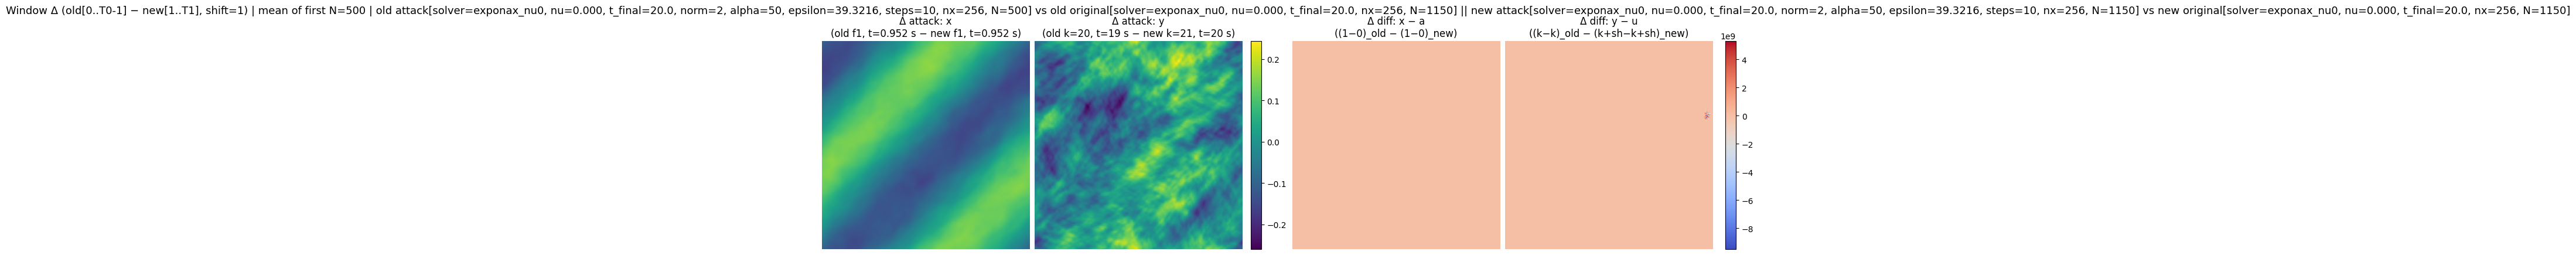

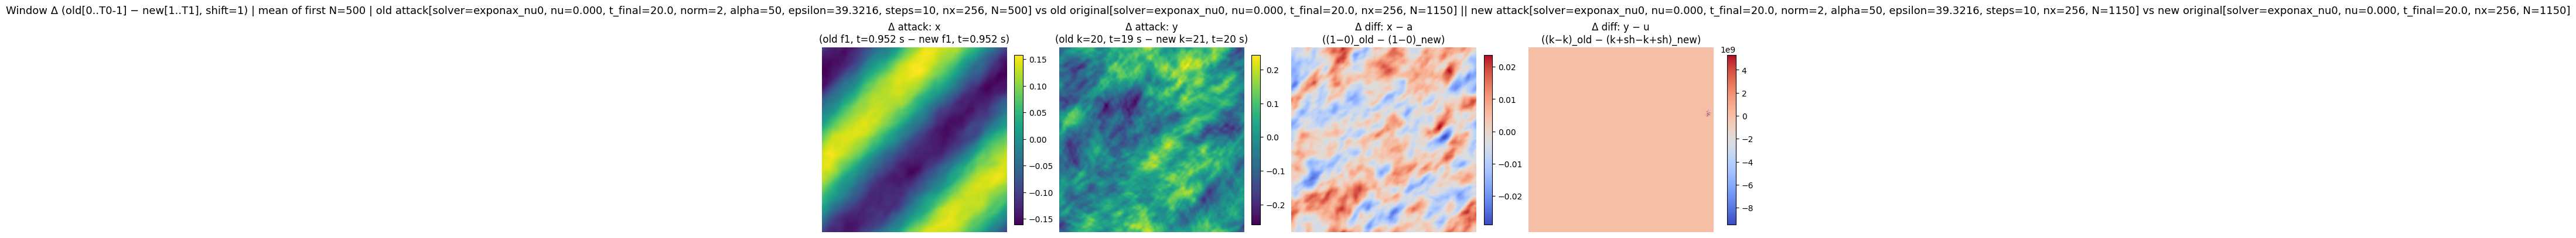

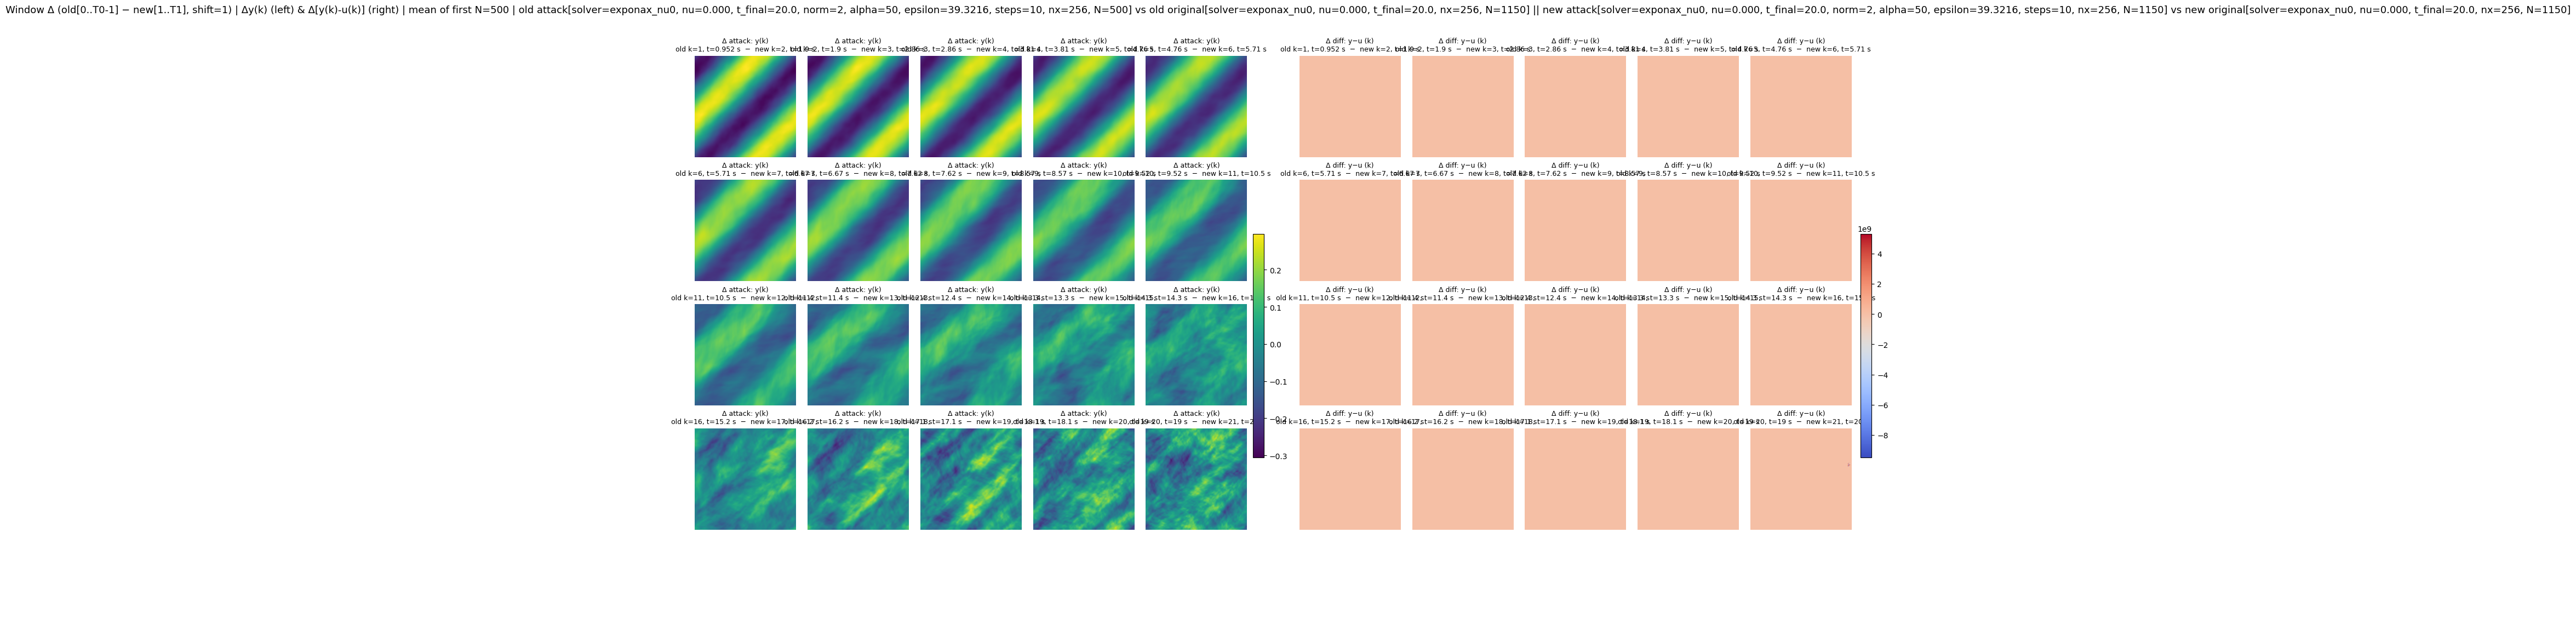

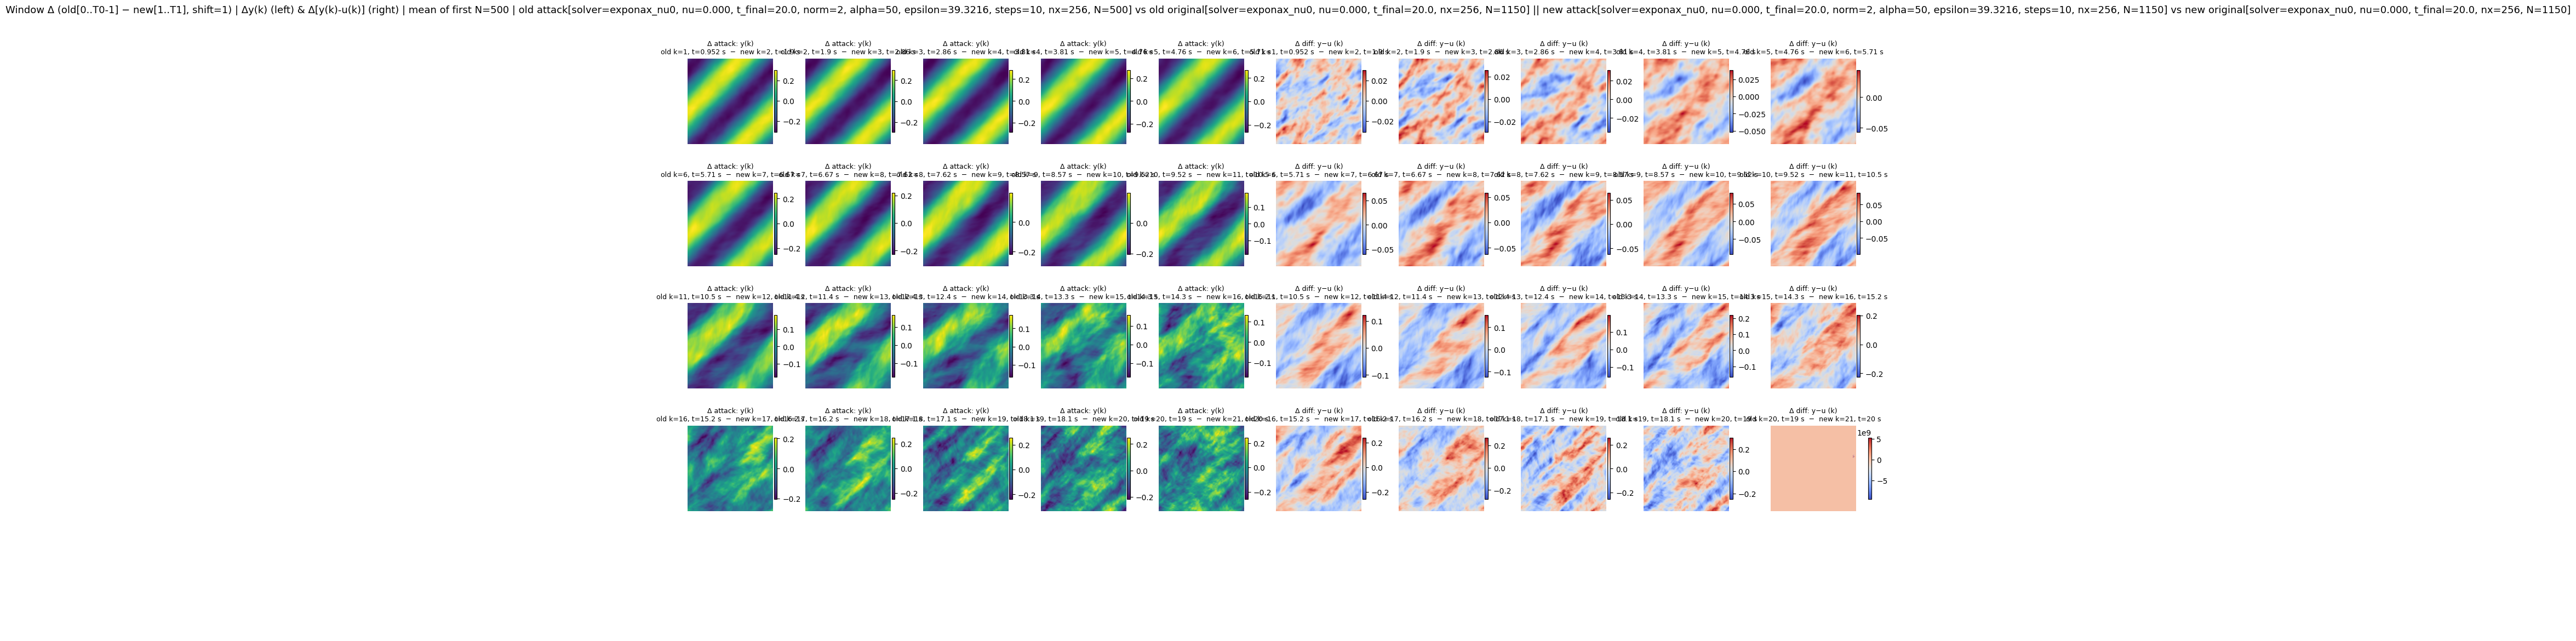

(<Figure size 2200x1100 with 90 Axes>,
 array([[<Axes: title={'center': 'Δ attack: y(k)\nold k=1, t=0.952 s  −  new k=2, t=1.9 s'}>,
         <Axes: title={'center': 'Δ attack: y(k)\nold k=2, t=1.9 s  −  new k=3, t=2.86 s'}>,
         <Axes: title={'center': 'Δ attack: y(k)\nold k=3, t=2.86 s  −  new k=4, t=3.81 s'}>,
         <Axes: title={'center': 'Δ attack: y(k)\nold k=4, t=3.81 s  −  new k=5, t=4.76 s'}>,
         <Axes: title={'center': 'Δ attack: y(k)\nold k=5, t=4.76 s  −  new k=6, t=5.71 s'}>,
         <Axes: title={'center': 'Δ diff: y−u (k)\nold k=1, t=0.952 s  −  new k=2, t=1.9 s'}>,
         <Axes: title={'center': 'Δ diff: y−u (k)\nold k=2, t=1.9 s  −  new k=3, t=2.86 s'}>,
         <Axes: title={'center': 'Δ diff: y−u (k)\nold k=3, t=2.86 s  −  new k=4, t=3.81 s'}>,
         <Axes: title={'center': 'Δ diff: y−u (k)\nold k=4, t=3.81 s  −  new k=5, t=4.76 s'}>,
         <Axes: title={'center': 'Δ diff: y−u (k)\nold k=5, t=4.76 s  −  new k=6, t=5.71 s'}>],
        [<Axes: t

In [3]:
sect = "alpha50_epsilon39.3216"

# 原来的“旧窗口”（0..19）：
pt_attack_old = f"dim2d_nx256_N500_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_{sect}_steps10.pt"
pt_original_old = "../../../exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

# 新增的“新窗口”（1..20，对齐 old 的 0..19）：
pt_attack_new = f"../../../../../2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=1150/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_{sect}_steps10.pt"
pt_original_new = "../../../../../2D_NS_FNO2d_recurrent/datasets/exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

# 单帧四图“窗口差分”：选旧窗里的第 20 帧（k=19），新窗会用 k+1=20
plot_xy_compare_shifted_diff_avg(
    pt_attack_old, pt_original_old,
    pt_attack_new, pt_original_new,
    N=500, t_idx=19, shift=1,
    cbar_mode="shared"
)
plot_xy_compare_shifted_diff_avg(
    pt_attack_old, pt_original_old,
    pt_attack_new, pt_original_new,
    N=500, t_idx=19, shift=1,
    cbar_mode="separate"
)
# 多帧格子“窗口差分”（默认 5×10，共 50 帧格子；会自动截断到 T_common）：
plot_frames_y_and_diff_side_by_side_avg_shifted_diff(
    pt_attack_old, pt_original_old,
    pt_attack_new, pt_original_new,
    N=500, grid=(5,5), shift=1,
    cbar_mode="shared"
)
plot_frames_y_and_diff_side_by_side_avg_shifted_diff(
    pt_attack_old, pt_original_old,
    pt_attack_new, pt_original_new,
    N=500, grid=(5,5), shift=1,
    cbar_mode="separate"
)

In [6]:
import torch, numpy as np, matplotlib.pyplot as plt

def plot_attack_original_firstframe_old_new(
    pt_attack_old, pt_original_old,
    pt_attack_new, pt_original_new,
    max_N=500,
    cmap="coolwarm",
    title_tag=""
):
    """
    读取四个数据，取“第一帧效应”，在共同 N（<=max_N）上做均值，画 2×4 个热图：
      Row 0: x(frame1)-a(frame0)  的 OLD / NEW / (OLD-NEW) / (NEW-OLD)
      Row 1: y(k=1)-u(k=1)        的 OLD / NEW / (OLD-NEW) / (NEW-OLD)
    标题明确：OLD [T=0...19], NEW [T=1...20]
    已放大标题与图的间距，防止被裁剪。
    """

    # ---------- helpers ----------
    def _load_pt(p):
        # weights_only=False，严格按你要求
        return torch.load(p, map_location="cpu", weights_only=False)

    def _to_np(t):
        if isinstance(t, torch.Tensor):
            return t.detach().cpu().numpy()
        return np.asarray(t)

    def _sym_vlim(*arrays):
        m = np.max([np.abs(a).max() for a in arrays])
        return (-m, m) if m > 0 else (-1.0, 1.0)

    def _stats(a):
        a = a.astype(np.float64, copy=False)
        mae = float(np.mean(np.abs(a)))
        rmse = float(np.sqrt(np.mean(a * a)))
        return mae, rmse

    # ---------- load ----------
    da0 = _load_pt(pt_attack_old)
    do0 = _load_pt(pt_original_old)
    da1 = _load_pt(pt_attack_new)
    do1 = _load_pt(pt_original_new)

    x0, y0 = da0["x"], da0["y"]      # OLD attack
    a0, u0 = do0["x"], do0["y"]      # OLD original
    x1, y1 = da1["x"], da1["y"]      # NEW attack
    a1, u1 = do1["x"], do1["y"]      # NEW original

    # ---------- sanity ----------
    for arr, nm in [(x0,"x0"),(a0,"a0"),(x1,"x1"),(a1,"a1")]:
        if arr.ndim != 3: raise ValueError(f"{nm} must be (N,H,W), got {tuple(arr.shape)}")
    for arr, nm in [(y0,"y0"),(u0,"u0"),(y1,"y1"),(u1,"u1")]:
        if arr.ndim != 4: raise ValueError(f"{nm} must be (N,H,W,T), got {tuple(arr.shape)}")
    if min(y0.shape[3], u0.shape[3], y1.shape[3], u1.shape[3]) < 1:
        raise ValueError("All y/u must have at least 1 frame (T>=1).")

    # ---------- common N ----------
    N_use = min(
        max_N, x0.shape[0], a0.shape[0], x1.shape[0], a1.shape[0],
        y0.shape[0], u0.shape[0], y1.shape[0], u1.shape[0]
    )

    # ---------- first-frame effects ----------
    # Row 0: x(frame1)-a(frame0)
    eff_xa_old = (x0[:N_use] - a0[:N_use]).mean(dim=0)          # (H,W)
    eff_xa_new = (x1[:N_use] - a1[:N_use]).mean(dim=0)          # (H,W)
    d_xa_old_new = eff_xa_old - eff_xa_new
    d_xa_new_old = -d_xa_old_new

    # Row 1: y(k=1)-u(k=1)  -> 索引 0
    eff_yu_old = (y0[:N_use, :, :, 0] - u0[:N_use, :, :, 0]).mean(dim=0)
    eff_yu_new = (y1[:N_use, :, :, 0] - u1[:N_use, :, :, 0]).mean(dim=0)
    d_yu_old_new = eff_yu_old - eff_yu_new
    d_yu_new_old = -d_yu_old_new

    # numpy
    eff_xa_old = _to_np(eff_xa_old); eff_xa_new = _to_np(eff_xa_new)
    d_xa_old_new = _to_np(d_xa_old_new); d_xa_new_old = _to_np(d_xa_new_old)
    eff_yu_old = _to_np(eff_yu_old); eff_yu_new = _to_np(eff_yu_new)
    d_yu_old_new = _to_np(d_yu_old_new); d_yu_new_old = _to_np(d_yu_new_old)

    # 对称色域（各行独立）
    vmin0, vmax0 = _sym_vlim(eff_xa_old, eff_xa_new, d_xa_old_new, d_xa_new_old)
    vmin1, vmax1 = _sym_vlim(eff_yu_old, eff_yu_new, d_yu_old_new, d_yu_new_old)

    # 指标（帮助判断强弱）
    mae_xo, rmse_xo = _stats(eff_xa_old)
    mae_xn, rmse_xn = _stats(eff_xa_new)
    mae_yo, rmse_yo = _stats(eff_yu_old)
    mae_yn, rmse_yn = _stats(eff_yu_new)

    # ---------- plot ----------
    # 放大画布，启用 constrained_layout；随后再调 layout pads 增加间距
    fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)

    # 让标题和图之间更“松”，并避免标题被裁剪（3.1+ 支持）
    try:
        fig.set_constrained_layout_pads(w_pad=0.08, h_pad=0.10, wspace=0.10, hspace=0.20)
    except Exception:
        # 老版本兜底：稍微留出顶部空间
        fig.subplots_adjust(top=0.90, wspace=0.15, hspace=0.25)

    title_pad = 10  # 每幅子图标题与图像的距离
    title_fs  = 10  # 子图标题字号

    # Row 0: x-a
    ims0 = []
    ims0.append(axes[0,0].imshow(eff_xa_old, cmap=cmap, vmin=vmin0, vmax=vmax0))
    axes[0,0].set_title(f"(x−a) OLD [T=0...19]\nMAE={mae_xo:.3g}, RMSE={rmse_xo:.3g}",
                        pad=title_pad, fontsize=title_fs); axes[0,0].axis("off")

    ims0.append(axes[0,1].imshow(eff_xa_new, cmap=cmap, vmin=vmin0, vmax=vmax0))
    axes[0,1].set_title(f"(x−a) NEW [T=1...20]\nMAE={mae_xn:.3g}, RMSE={rmse_xn:.3g}",
                        pad=title_pad, fontsize=title_fs); axes[0,1].axis("off")

    ims0.append(axes[0,2].imshow(d_xa_old_new, cmap=cmap, vmin=vmin0, vmax=vmax0))
    axes[0,2].set_title("(x−a) OLD−NEW [T=0...19 − T=1...20]",
                        pad=title_pad, fontsize=title_fs); axes[0,2].axis("off")

    ims0.append(axes[0,3].imshow(d_xa_new_old, cmap=cmap, vmin=vmin0, vmax=vmax0))
    axes[0,3].set_title("(x−a) NEW−OLD [T=1...20 − T=0...19]",
                        pad=title_pad, fontsize=title_fs); axes[0,3].axis("off")

    # Row 1: y-u
    ims1 = []
    ims1.append(axes[1,0].imshow(eff_yu_old, cmap=cmap, vmin=vmin1, vmax=vmax1))
    axes[1,0].set_title(f"(y₁−u₁) OLD [T=0...19]\nMAE={mae_yo:.3g}, RMSE={rmse_yo:.3g}",
                        pad=title_pad, fontsize=title_fs); axes[1,0].axis("off")

    ims1.append(axes[1,1].imshow(eff_yu_new, cmap=cmap, vmin=vmin1, vmax=vmax1))
    axes[1,1].set_title(f"(y₁−u₁) NEW [T=1...20]\nMAE={mae_yn:.3g}, RMSE={rmse_yn:.3g}",
                        pad=title_pad, fontsize=title_fs); axes[1,1].axis("off")

    ims1.append(axes[1,2].imshow(d_yu_old_new, cmap=cmap, vmin=vmin1, vmax=vmax1))
    axes[1,2].set_title("(y₁−u₁) OLD−NEW [T=0...19 − T=1...20]",
                        pad=title_pad, fontsize=title_fs); axes[1,2].axis("off")

    ims1.append(axes[1,3].imshow(d_yu_new_old, cmap=cmap, vmin=vmin1, vmax=vmax1))
    axes[1,3].set_title("(y₁−u₁) NEW−OLD [T=1...20 − T=0...19]",
                        pad=title_pad, fontsize=title_fs); axes[1,3].axis("off")

    # 共用色条（每行一根），加大 pad 防止压到标题
    fig.colorbar(ims0[-1], ax=axes[0,:].ravel().tolist(), fraction=0.025, pad=0.02)
    fig.colorbar(ims1[-1], ax=axes[1,:].ravel().tolist(), fraction=0.025, pad=0.02)

    # 大标题：让 constrained_layout 接管位置，不手动设 y，避免越界
    fig.suptitle(
        f"Attack − Original on FIRST FRAME (mean over N={N_use}) | "
        f"OLD (T=0...19) vs NEW (T=1...20) {title_tag}",
        fontsize=14
    )

    plt.show()
    return fig, axes



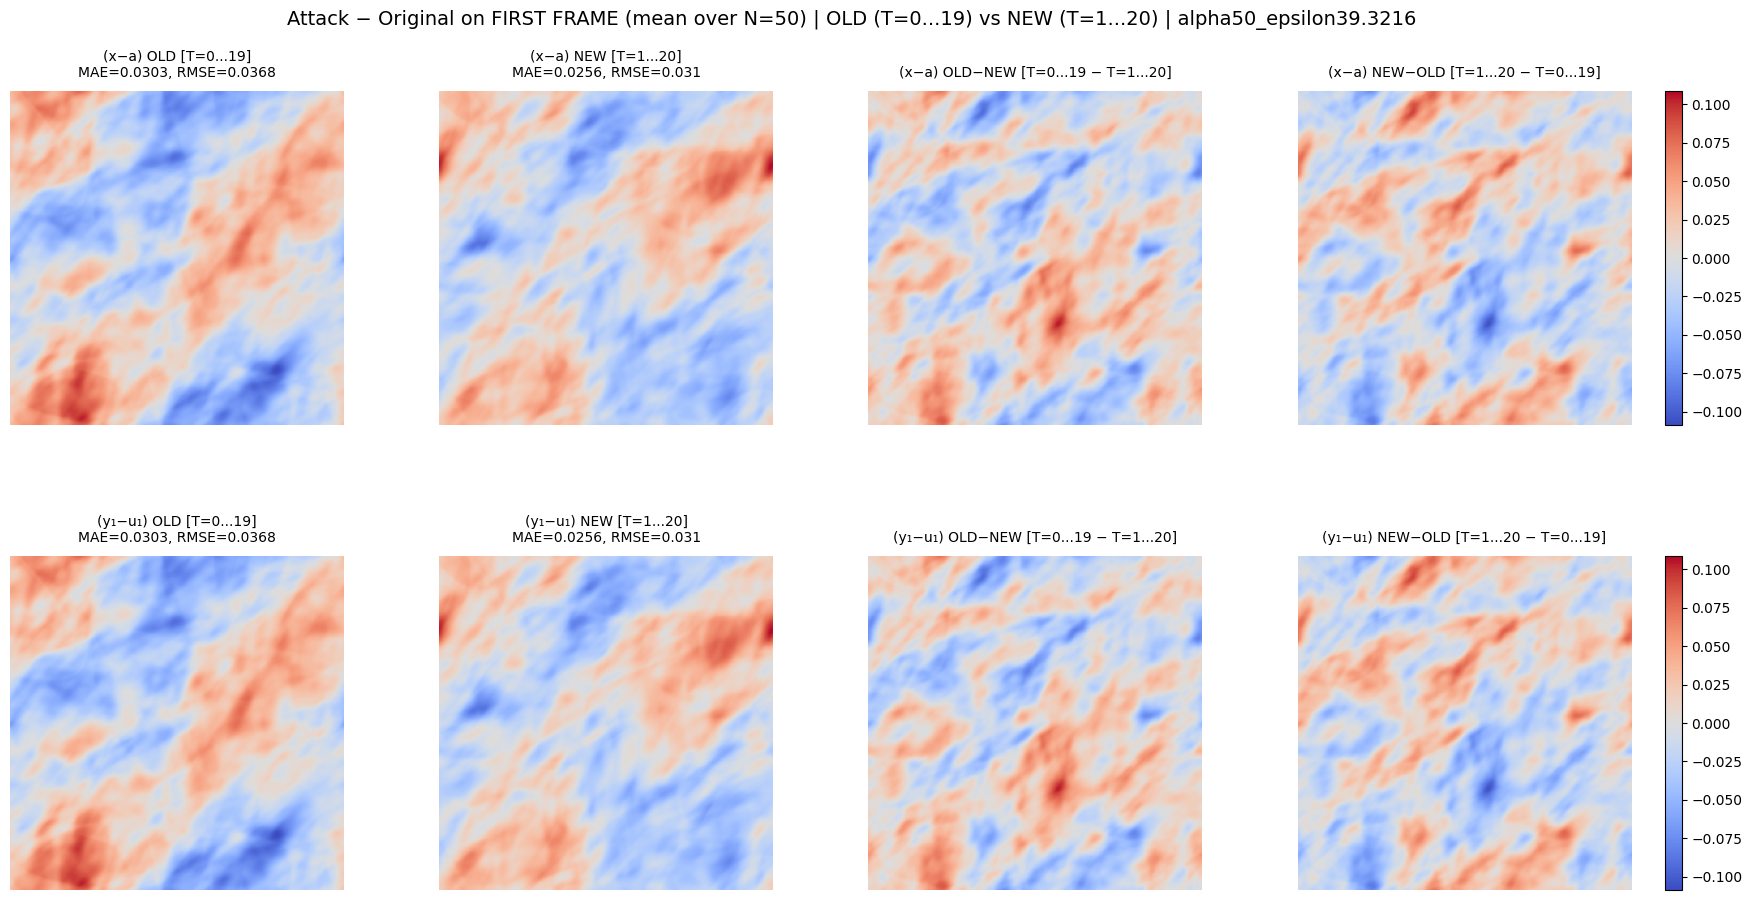

(<Figure size 1800x900 with 10 Axes>,
 array([[<Axes: title={'center': '(x−a) OLD [T=0...19]\nMAE=0.0303, RMSE=0.0368'}>,
         <Axes: title={'center': '(x−a) NEW [T=1...20]\nMAE=0.0256, RMSE=0.031'}>,
         <Axes: title={'center': '(x−a) OLD−NEW [T=0...19 − T=1...20]'}>,
         <Axes: title={'center': '(x−a) NEW−OLD [T=1...20 − T=0...19]'}>],
        [<Axes: title={'center': '(y₁−u₁) OLD [T=0...19]\nMAE=0.0303, RMSE=0.0368'}>,
         <Axes: title={'center': '(y₁−u₁) NEW [T=1...20]\nMAE=0.0256, RMSE=0.031'}>,
         <Axes: title={'center': '(y₁−u₁) OLD−NEW [T=0...19 − T=1...20]'}>,
         <Axes: title={'center': '(y₁−u₁) NEW−OLD [T=1...20 − T=0...19]'}>]],
       dtype=object))

In [15]:
sect = "alpha50_epsilon39.3216"

pt_attack_old = f"dim2d_nx256_N500_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_{sect}_steps10.pt"
pt_original_old = "../../../exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

pt_attack_new = f"../../../../../2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=1150/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_{sect}_steps10.pt"
pt_original_new = "../../../../../2D_NS_FNO2d_recurrent/datasets/exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

plot_attack_original_firstframe_old_new(
    pt_attack_old, pt_original_old,
    pt_attack_new, pt_original_new,
    max_N=50,
    cmap="coolwarm",
    title_tag=f"| {sect}"
)


In [9]:
import torch, numpy as np, matplotlib.pyplot as plt

def plot_attack_original_firstframe_old_new_lines(
    pt_attack_old, pt_original_old,
    pt_attack_new, pt_original_new,
    max_N=500,
    centered_x=True,         # True: 横轴为 -(H-1)..(H-1) 更对称；False: 0..2H-2
    title_tag="",
):
    """
    读取四个数据，取“第一帧效应”，在共同 N(<=max_N) 上做均值，
    再将每幅 2D 效应图沿 NE→SW(右上→左下) 方向做周期对角均值，画成 2×4 折线图：
      Row 0: (x−a) 的 OLD / NEW / (OLD−NEW) / (NEW−OLD)
      Row 1: (y₁−u₁) 的 OLD / NEW / (OLD−NEW) / (NEW−OLD)
    """

    # ---------- helpers ----------
    def _load_pt(p):
        return torch.load(p, map_location="cpu", weights_only=False)

    def _to_np(t):
        if isinstance(t, torch.Tensor):
            return t.detach().cpu().numpy()
        return np.asarray(t)

    def _diag45_periodic_mean(arr2d: np.ndarray) -> np.ndarray:
        """
        沿 NE→SW (保持 r+c 常数) 做周期对角均值。
        返回长度 2H-1 的序列，且每个点均为恰好 H 个元素的平均（通过列索引取模实现）。
        """
        A = np.asarray(arr2d)
        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            raise ValueError(f"需要方阵 2D 数组，当前形状: {A.shape}")
        H = A.shape[0]
        r = np.arange(H)
        out = np.empty(2*H - 1, dtype=float)
        for k in range(2*H - 1):
            c = (k - r) % H          # 保持 r+c=k (mod H)
            out[k] = A[r, c].mean()  # 每个位置平均 H 个值
        return out

    def _sym_ylim(*series):
        m = float(np.max([np.abs(s).max() if len(s) else 0.0 for s in series]))
        m = 1.0 if m == 0 else m
        return (-m, m)

    # ---------- load ----------
    da0 = _load_pt(pt_attack_old)
    do0 = _load_pt(pt_original_old)
    da1 = _load_pt(pt_attack_new)
    do1 = _load_pt(pt_original_new)

    x0, y0 = da0["x"], da0["y"]      # OLD attack
    a0, u0 = do0["x"], do0["y"]      # OLD original
    x1, y1 = da1["x"], da1["y"]      # NEW attack
    a1, u1 = do1["x"], do1["y"]      # NEW original

    # ---------- sanity ----------
    for arr, nm in [(x0,"x0"),(a0,"a0"),(x1,"x1"),(a1,"a1")]:
        if arr.ndim != 3: raise ValueError(f"{nm} 必须是 (N,H,W)，得到 {tuple(arr.shape)}")
    for arr, nm in [(y0,"y0"),(u0,"u0"),(y1,"y1"),(u1,"u1")]:
        if arr.ndim != 4: raise ValueError(f"{nm} 必须是 (N,H,W,T)，得到 {tuple(arr.shape)}")

    H, W = x0.shape[1], x0.shape[2]
    if H != W: raise ValueError(f"当前仅支持方阵 H==W，得到 H={H}, W={W}")

    if min(y0.shape[3], u0.shape[3], y1.shape[3], u1.shape[3]) < 1:
        raise ValueError("所有 y/u 需至少 1 帧 (T>=1)")

    # ---------- common N ----------
    N_use = min(
        max_N, x0.shape[0], a0.shape[0], x1.shape[0], a1.shape[0],
        y0.shape[0], u0.shape[0], y1.shape[0], u1.shape[0]
    )

    # ---------- first-frame effects (2D) ----------
    # Row 0: x(frame1)-a(frame0)
    eff_xa_old = (x0[:N_use] - a0[:N_use]).mean(dim=0)                      # (H,W)
    eff_xa_new = (x1[:N_use] - a1[:N_use]).mean(dim=0)                      # (H,W)
    d_xa_old_new = eff_xa_old - eff_xa_new                                  # (H,W)
    d_xa_new_old = -d_xa_old_new

    # Row 1: y(k=1)-u(k=1) -> 索引 0
    eff_yu_old = (y0[:N_use, :, :, 0] - u0[:N_use, :, :, 0]).mean(dim=0)    # (H,W)
    eff_yu_new = (y1[:N_use, :, :, 0] - u1[:N_use, :, :, 0]).mean(dim=0)    # (H,W)
    d_yu_old_new = eff_yu_old - eff_yu_new                                  # (H,W)
    d_yu_new_old = -d_yu_old_new

    # ---------- NE→SW 周期对角均值 (1D) ----------
    xa_old_1d = _diag45_periodic_mean(_to_np(eff_xa_old))
    xa_new_1d = _diag45_periodic_mean(_to_np(eff_xa_new))
    xa_on_1d  = _diag45_periodic_mean(_to_np(d_xa_old_new))
    xa_no_1d  = _diag45_periodic_mean(_to_np(d_xa_new_old))

    yu_old_1d = _diag45_periodic_mean(_to_np(eff_yu_old))
    yu_new_1d = _diag45_periodic_mean(_to_np(eff_yu_new))
    yu_on_1d  = _diag45_periodic_mean(_to_np(d_yu_old_new))
    yu_no_1d  = _diag45_periodic_mean(_to_np(d_yu_new_old))

    # 横轴
    x_axis = (np.arange(2*H - 1) - (H - 1)) if centered_x else np.arange(2*H - 1)

    # 行内对称 y 轴
    ylim_row0 = _sym_ylim(xa_old_1d, xa_new_1d, xa_on_1d, xa_no_1d)
    ylim_row1 = _sym_ylim(yu_old_1d, yu_new_1d, yu_on_1d, yu_no_1d)

    # ---------- plot lines (2×4) ----------
    fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
    try:
        fig.set_constrained_layout_pads(w_pad=0.08, h_pad=0.10, wspace=0.12, hspace=0.25)
    except Exception:
        fig.subplots_adjust(top=0.90, wspace=0.18, hspace=0.30)

    # 通用绘制函数
    def _one(ax, x, y, title, ylim):
        ax.plot(x, y, linewidth=1.6)
        ax.set_ylim(*ylim)
        ax.grid(True, alpha=0.35)
        ax.set_title(title, pad=10, fontsize=10)
        # 只在左列标注 ylabel，底行标注 xlabel，避免重复
        ax.tick_params(labelsize=9)

    # Row 0: (x−a)
    _one(axes[0,0], x_axis, xa_old_1d, "(x−a) OLD [T=0...19]", ylim_row0)
    _one(axes[0,1], x_axis, xa_new_1d, "(x−a) NEW [T=1...20]", ylim_row0)
    _one(axes[0,2], x_axis, xa_on_1d,  "(x−a) OLD−NEW [T=0...19 − T=1...20]", ylim_row0)
    _one(axes[0,3], x_axis, xa_no_1d,  "(x−a) NEW−OLD [T=1...20 − T=0...19]", ylim_row0)

    # Row 1: (y₁−u₁)
    _one(axes[1,0], x_axis, yu_old_1d, "(y₁−u₁) OLD [T=0...19]", ylim_row1)
    _one(axes[1,1], x_axis, yu_new_1d, "(y₁−u₁) NEW [T=1...20]", ylim_row1)
    _one(axes[1,2], x_axis, yu_on_1d,  "(y₁−u₁) OLD−NEW [T=0...19 − T=1...20]", ylim_row1)
    _one(axes[1,3], x_axis, yu_no_1d,  "(y₁−u₁) NEW−OLD [T=1...20 − T=0...19]", ylim_row1)

    # 轴标签（左列与底行）
    for c in range(4):
        axes[1, c].set_xlabel("对角索引 (NE→SW)" + (" | centered" if centered_x else ""), fontsize=10)
    for r in range(2):
        axes[r, 0].set_ylabel("周期对角均值", fontsize=10)

    # 总标题
    fig.suptitle(
        f"Diagonal (NE→SW) Periodic Mean of FIRST-FRAME Effects (mean over N={N_use}) | "
        f"OLD (T=0...19) vs NEW (T=1...20) {title_tag}",
        fontsize=14
    )

    plt.show()
    return fig, axes


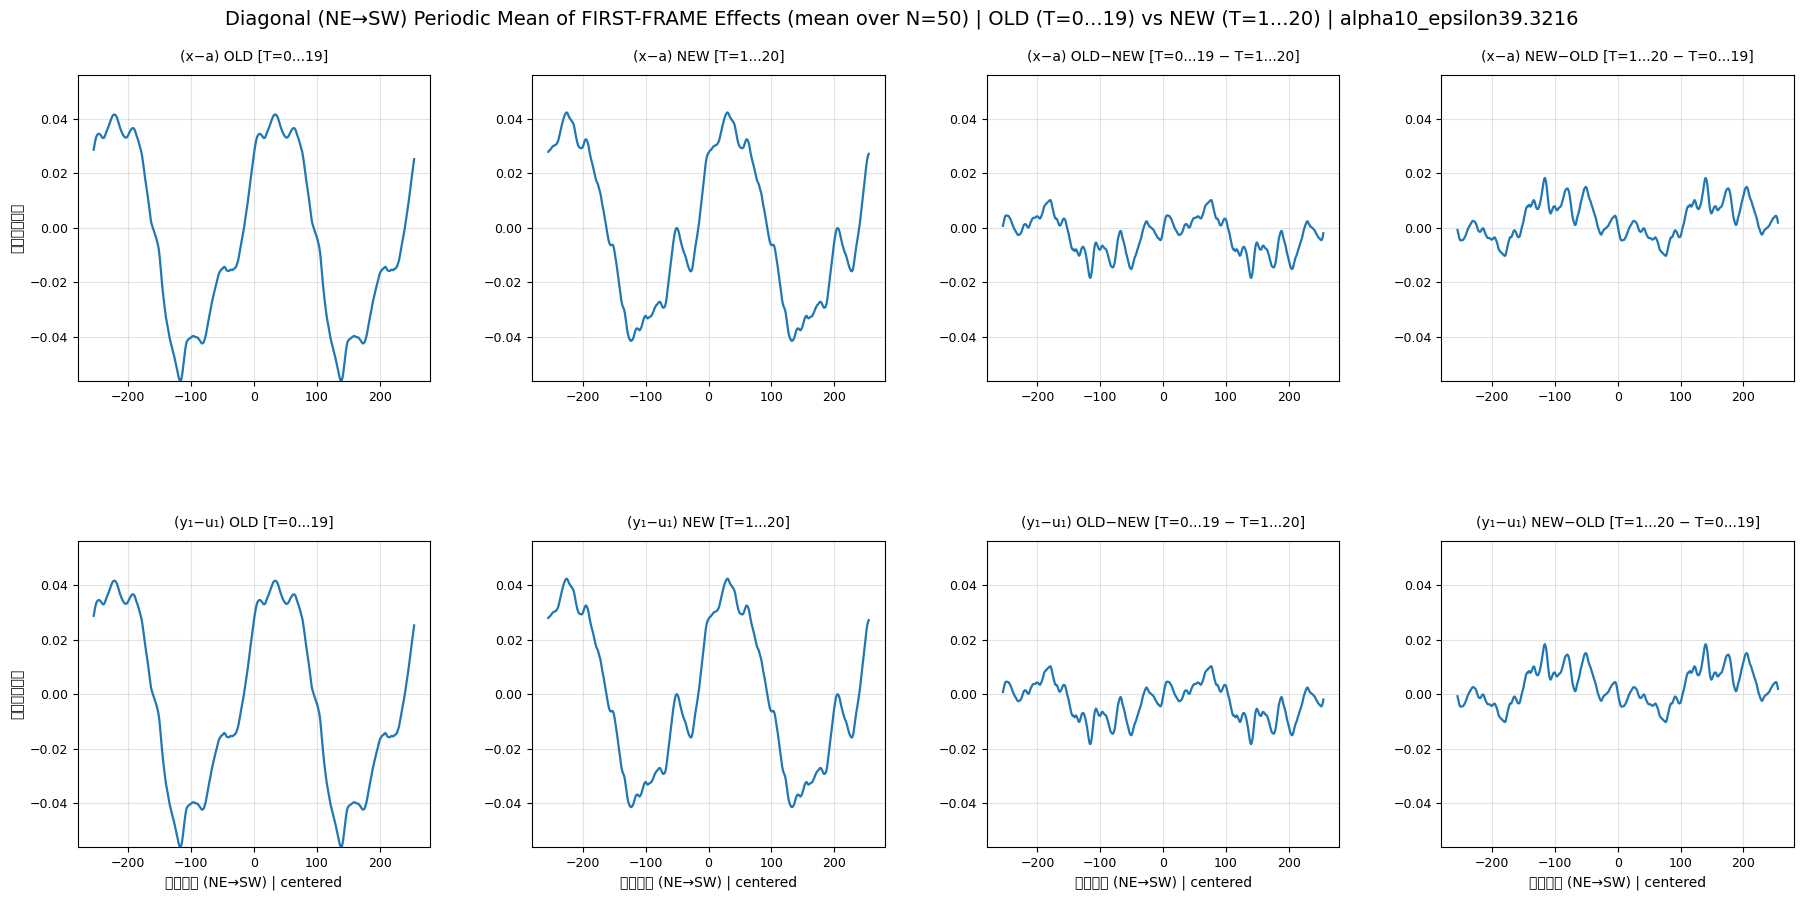

(<Figure size 1800x900 with 8 Axes>,
 array([[<Axes: title={'center': '(x−a) OLD [T=0...19]'}, ylabel='周期对角均值'>,
         <Axes: title={'center': '(x−a) NEW [T=1...20]'}>,
         <Axes: title={'center': '(x−a) OLD−NEW [T=0...19 − T=1...20]'}>,
         <Axes: title={'center': '(x−a) NEW−OLD [T=1...20 − T=0...19]'}>],
        [<Axes: title={'center': '(y₁−u₁) OLD [T=0...19]'}, xlabel='对角索引 (NE→SW) | centered', ylabel='周期对角均值'>,
         <Axes: title={'center': '(y₁−u₁) NEW [T=1...20]'}, xlabel='对角索引 (NE→SW) | centered'>,
         <Axes: title={'center': '(y₁−u₁) OLD−NEW [T=0...19 − T=1...20]'}, xlabel='对角索引 (NE→SW) | centered'>,
         <Axes: title={'center': '(y₁−u₁) NEW−OLD [T=1...20 − T=0...19]'}, xlabel='对角索引 (NE→SW) | centered'>]],
       dtype=object))

In [13]:
sect = "alpha10_epsilon39.3216"

pt_attack_old = f"dim2d_nx256_N500_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_{sect}_steps10.pt"
pt_original_old = "../../../exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

pt_attack_new = f"../../../../../2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=1150/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_{sect}_steps10.pt"
pt_original_new = "../../../../../2D_NS_FNO2d_recurrent/datasets/exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

plot_attack_original_firstframe_old_new_lines(
    pt_attack_old, pt_original_old,
    pt_attack_new, pt_original_new,
    max_N=50,
    centered_x=True,
    title_tag=f"| {sect}"
)
